## Análise de perguntas frequentes

In [1]:
import os
import torch
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA


pd.set_option('display.max_colwidth', None)

DATA_PATH_QUESTIONS = '../topic_analysis_gravidez_results_two_steps_api/retained_questions_with_topics.csv'
DATA_PATH_COMMENTS = '../data/cleaned/cleaned_comments_info.csv'
DATA_PATH_QUERIES = '../CrawlerYTGabriel/files/queries.txt'
OUTPUT_PATH_FIGS = '../data/figs/'
OUTPUT_PATH_EMBEDDINGS = '../data/cleaned/embeddings/'
OUTPUT_PATH_SAMPLES = '../data/cleaned/sim_samples.csv'

MODEL_ID = 'google/embeddinggemma-300m'
MODEL_NAME = MODEL_ID.split('/')[-1]
EMBEDDING_TASK = 'sentence_similarity'
EMBEDDING_DATASET = 'retained_questions'

LIMIAR_POS = 0.80
LIMIAR_NEG = 0.50

# cria pasta para salvar embeddings caso não exista
os.makedirs(OUTPUT_PATH_EMBEDDINGS, exist_ok=True)

### Carregamento e preparação dos dados

In [2]:
TERMS = []

with open(DATA_PATH_QUERIES, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if line:
            TERMS.append(line)

print(TERMS)

['Como ter certeza que estou grávida?', 'Quando devo começar as visitas ao pré-natal?', 'Onde posso fazer o pré-natal?', 'Quantas consultas de pré-natal será bom para mim e para meu bebê?', 'O que devo fazer se eu me sentir mal antes da data da próxima consulta?', 'Quanto tempo dura a gravidez?', 'O que é parto prematuro?', 'Como vou contar o tempo de gravidez: meses ou semanas?', 'A gravidez pode durar mais do que 9 meses?', 'O que é data provável para o parto?', 'Ter infecção de urina aumenta a chance de parto prematuro?', 'Posso tomar os remédios que já tenho costume de usar quando sinto dor?', 'O que posso fazer para evitar o parto prematuro?', 'Estou sentindo contrações antes do nono mês. É normal?', 'A partir de quando posso saber o sexo do bebê durante a gravidez?', 'Tem como saber o peso do bebê dentro do útero?', 'A partir de quando o embrião aparece dentro do meu útero?', 'A partir de quando o feto se forma?', 'A partir de quando o bebê começa a mexer dentro do útero?', 'Quan

In [3]:
df_questions = pd.read_csv(DATA_PATH_QUESTIONS)
questions_ids = df_questions['comment_id'].tolist()
df_questions_plot = (
    df_questions
    .dropna(subset=['perguntas'])
    .copy()
)

questions_comments = df_questions_plot['perguntas'].astype(str).tolist()
topics_comments = df_questions_plot['topic_id'].astype(str).tolist()
topic_names = df_questions_plot['Name'].fillna('Sem tópico').tolist()

df_questions.shape, len(questions_comments)

((11676, 8), 11676)

### Cálculo dos embeddings

In [4]:
cache_prefix = f'{MODEL_NAME}_{EMBEDDING_TASK}_{EMBEDDING_DATASET}'
path_comments = os.path.join(OUTPUT_PATH_EMBEDDINGS, f'{cache_prefix}_comments.pt')
path_queries = os.path.join(OUTPUT_PATH_EMBEDDINGS, f'{cache_prefix}_queries.pt')

# carrega o modelo apenas quando algum embedding ainda não foi calculado
if not os.path.exists(path_comments) or not os.path.exists(path_queries):
    MODEL = SentenceTransformer(MODEL_ID)

questions_comments_for_embedding = [
    f'task: sentence similarity | query: {question}'
    for question in questions_comments
]
terms_for_embedding = [
    f'task: sentence similarity | query: {term}'
    for term in TERMS
]

# embeddings das perguntas contidas nos comentários
if os.path.exists(path_comments):
    embed_questions_comments = torch.load(path_comments)
else:
    embed_questions_comments = MODEL.encode(
        questions_comments_for_embedding,
        convert_to_tensor=True,
        normalize_embeddings=True,
    ) # pyright: ignore[reportPossiblyUnboundVariable]
    torch.save(embed_questions_comments, path_comments)

if os.path.exists(path_queries):
    embed_questions_queries = torch.load(path_queries)
else:
    embed_questions_queries = MODEL.encode(
        terms_for_embedding,
        convert_to_tensor=True,
        normalize_embeddings=True,
    ) # pyright: ignore[reportPossiblyUnboundVariable]
    torch.save(embed_questions_queries, path_queries)

### Cálculo de similaridade

In [5]:
# uma matriz onde cada linha representa uma query e cada coluna representa uma pergunta, e o valor é a similaridade entre eles
similaridades = util.cos_sim(embed_questions_queries.float(), embed_questions_comments.float())

In [6]:
embed_questions_queries.shape, embed_questions_comments.shape, similaridades.shape

(torch.Size([98, 768]), torch.Size([11676, 768]), torch.Size([98, 11676]))

In [7]:
results_high_sim = []
thresholds = np.arange(0.50, 1.01, 0.1)

for threshold in thresholds:
    # Para cada pergunta, verifica se alguma query passa do limiar
    questions_above_threshold = (similaridades >= threshold).any(dim=0)

    results_high_sim.append({
        'threshold': threshold,
        'num_questions': questions_above_threshold.sum().item(),
        'pct_questions': questions_above_threshold.float().mean().item() * 100
    })

results_high_sim_df = pd.DataFrame(results_high_sim)
results_high_sim_df

,threshold,num_questions,pct_questions
0,0.5,11667,99.922919
1,0.6,11349,97.199386
2,0.7,7846,67.197669
3,0.8,1536,13.155191
4,0.9,76,0.650908
5,1.0,0,0.000000


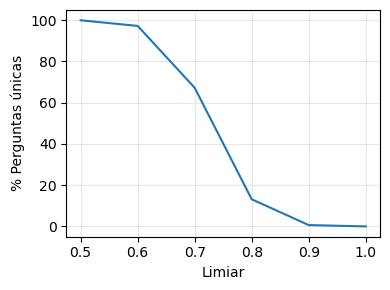

In [8]:
plt.figure(figsize=(4, 3))

plt.plot(
    results_high_sim_df['threshold'],
    results_high_sim_df['pct_questions'],
)

plt.xlabel('Limiar')
plt.ylabel('% Perguntas únicas')
plt.xticks(results_high_sim_df['threshold'])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, f'{cache_prefix}_pct_questions_vs_threshold.png'))
plt.show()

In [9]:
results_high_sim = []

for i, query in enumerate(TERMS):
    # pega as similaridades da query com todas as perguntas
    scores = similaridades[i]
    indices = scores.argsort(descending=True)

    # pega o número de perguntas que passam do limiar
    num_comments = (scores >= LIMIAR_POS).sum().item()
    results_high_sim.append({
        'pergunta': query,
        'num_perguntas': num_comments,
        'perguntas': [questions_comments[idx] for idx in indices[:num_comments].tolist()],
        'similaridades': [scores[idx].item() for idx in indices[:num_comments].tolist()]
    })

df_results_high = pd.DataFrame(results_high_sim).sort_values(by='num_perguntas', ascending=False).reset_index(drop=True)
df_results_high[['pergunta', 'num_perguntas']].head()

,pergunta,num_perguntas
0,"Já tive uma cesárea, posso ter parto normal na próxima gestação?",187
1,Como ter certeza que estou grávida?,147
2,Como posso ter alívio da dor durante o parto?,126
3,A gravidez pode durar mais do que 9 meses?,114
4,Como vou contar o tempo de gravidez: meses ou semanas?,105


In [10]:
df_results_high[['pergunta', 'num_perguntas']].tail()

,pergunta,num_perguntas
93,É proibido fazer exame de prevenção do câncer do útero na gravidez?,0
94,Minha gengiva está sangrando quando escovo os dentes. O que fazer?,0
95,O que é Teste do Olhinho?,0
96,O que é Teste da Orelhinha?,0
97,Pode sair algum tipo de secreção da região dos pontos? Quando devo me preocupar?,0


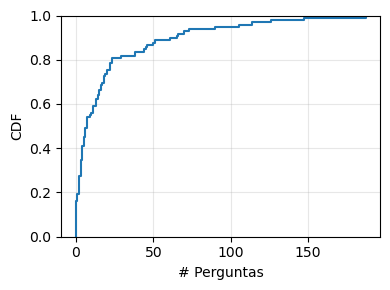

In [11]:
plt.figure(figsize=(4, 3))
sns.ecdfplot(
    data=df_results_high,
    x='num_perguntas'
)
plt.xlabel('# Perguntas')
plt.ylabel('CDF')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, f'{cache_prefix}_cdf_num_questions.png'))
plt.show()

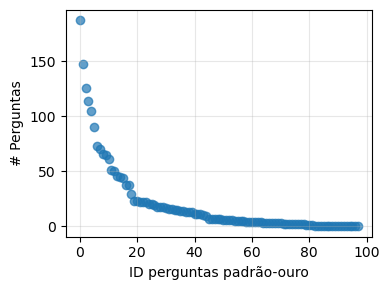

In [12]:
df_gold_counts = (
    df_results_high
    .sort_values('num_perguntas', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(4, 3))

plt.scatter(
    x=df_gold_counts.index,
    y=df_gold_counts['num_perguntas'],
    alpha=0.7,
)

plt.xlabel('ID perguntas padrão-ouro')
plt.ylabel('# Perguntas')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, f'{cache_prefix}_num_questions_vs_gold_questions.png'))
plt.show()

In [13]:
df_results_high[df_results_high['num_perguntas'] == 0].shape, df_results_high[df_results_high['num_perguntas'] != 0].shape

((16, 4), (82, 4))

In [14]:
df_results_high = df_results_high.explode(['perguntas', 'similaridades']).reset_index(drop=True)
df_results_high = df_results_high[df_results_high['num_perguntas'] > 0]
df_results_high.shape

(2011, 4)

In [15]:
df_results_high.sample(5)

,pergunta,num_perguntas,perguntas,similaridades
1428,Estou sentindo contrações antes do nono mês. É normal?,29,"É normal sentir muitas contrações de treinamento, cólicas, barriga baixa, peso, vontade de urinar e pressão na região íntima nessa fase da gravidez?",0.821299
913,Qual é a melhor posição no parto?,66,Qual é a melhor posição para o parto?,0.994525
986,Quais são os cuidado com os pontos da cesariana?,65,A retirada dos pontos da cesariana doeu?,0.848442
1659,"Posso tomar os remédios que já usava antes, durante a gestação?",18,Estou grávida; posso tomar esse suplemento sem prejudicar o bebê?,0.81882
1270,Ter um pouco de dor na barriga é normal?,45,"É normal sentir muito movimento e pontadas rápidas na barriga, como se estivesse grávida de três meses?",0.818121


In [16]:
df_sample = df_results_high[['pergunta', 'perguntas', 'similaridades']].sample(100, random_state=42)
df_sample.to_csv(OUTPUT_PATH_SAMPLES, index=False)

### Perguntas distantes

In [17]:
max_similaridades_ext, indices_ref_ext = similaridades.max(dim=0)
max_similaridades_ref, indices_ext_ref = similaridades.max(dim=1)

df_ext_irrelev = pd.DataFrame({
    "pergunta": questions_comments,
    "referencia_mais_proxima": [
        TERMS[i] for i in indices_ref_ext.cpu().tolist()
    ],
    "max_similaridade": max_similaridades_ext.cpu().tolist(),
})

df_ext_irrelev = (
    df_ext_irrelev[
        df_ext_irrelev["max_similaridade"] < LIMIAR_NEG
    ]
    .sort_values("max_similaridade")
    .reset_index(drop=True)
)

df_ref_irrelev = pd.DataFrame({
    "pergunta_referencia": TERMS,
    "pergunta_extraida_mais_proxima": [
        questions_comments[i] for i in indices_ext_ref.cpu().tolist()
    ],
    "max_similaridade": max_similaridades_ref.cpu().tolist(),
})

df_ref_irrelev = (
    df_ref_irrelev[
        df_ref_irrelev["max_similaridade"] < LIMIAR_POS
    ]
    .sort_values("max_similaridade")
    .reset_index(drop=True)
)

In [18]:
df_ref_irrelev.head()

,pergunta_referencia,pergunta_extraida_mais_proxima,max_similaridade
0,Posso beber nos finais de semana?,Gestantes podem tomar refrigerante uma vez por semana?,0.699429
1,O que devo fazer se eu me sentir mal antes da data da próxima consulta?,O que devo fazer diante desses sintomas na gestação?,0.727913
2,Minha gengiva está sangrando quando escovo os dentes. O que fazer?,O que devo fazer se estiver saindo da minha região íntima algo branco com aparência de sangramento arterial?,0.732009
3,Quando devo tomar sol nos seios?,"Para recém-nascidos, ainda é recomendado banho de sol ou agora é preferível fazer passeios no final da tarde e de manhã?",0.739270
4,Posso tomar os remédios que já tenho costume de usar quando sinto dor?,"Posso tomar hoje as duas pílulas, a de ontem e a de hoje, no horário das 17h35?",0.744123


In [19]:
df_ext_irrelev.head()

,pergunta,referencia_mais_proxima,max_similaridade
0,Quem é MEI precisa seguir o mesmo processo de pagamento da guia exigido para quem não trabalha?,"Se eu não tiver força pra empurrar o bebe, será que alguém empurra minha barriga?",0.439055
1,"Por que o benefício foi fixado no salário mínimo vigente de R$ 1.302, se esse não é o valor atual?",O que é Teste do Pezinho?,0.451827
2,"Qual guia do INSS devo pagar: a contribuição facultativa mensal com salário de R$ 2.000 e parcela de R$ 400, a contribuição facultativa de 11% com salário de R$ 1.518 e parcela de R$ 300, ou a guia de baixa renda com salário de R$ 1.518 e parcela de R$ 75,90?",Quantas consultas de pré-natal será bom para mim e para meu bebê?,0.474634
3,O código 1473 de contribuinte facultativo serve para quem recebe Bolsa Família?,Preciso levar o cartão de pré-natal no dia do parto?,0.482579
4,"Por que está havendo desconto de R$ 300 por mês, totalizando R$ 1.200?",Posso beber nos finais de semana?,0.485026


### Visualização dos dados

In [20]:
queries = F.normalize(
    embed_questions_queries.float(),
    p=2,
    dim=1
).cpu().numpy()

comments = F.normalize(
    embed_questions_comments.float(),
    p=2,
    dim=1
).cpu().numpy()

X = np.vstack([queries, comments])

In [21]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X)

tsne = TSNE(
    n_components=2,
    random_state=42,
    init='pca',
)

X_2d = tsne.fit_transform(X_pca)

n_queries = len(queries)
queries_2d = X_2d[:n_queries]
comments_2d = X_2d[n_queries:]

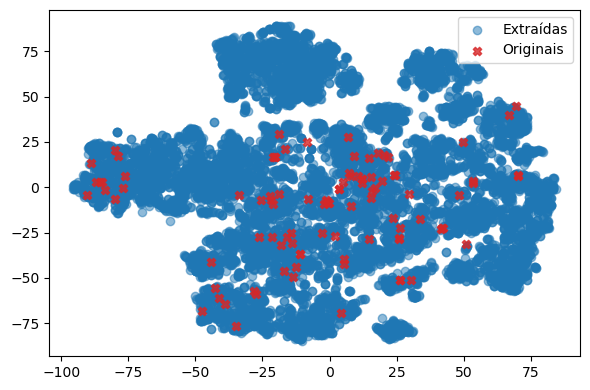

In [22]:
plt.figure(figsize=(6, 4))

plt.scatter(
    comments_2d[:, 0],
    comments_2d[:, 1],
    alpha=0.5,
    color='tab:blue',
    label='Extraídas'
)

plt.scatter(
    queries_2d[:, 0],
    queries_2d[:, 1],
    alpha=0.8,
    marker='X',
    color='tab:red',
    label='Originais'
)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, f'tsne_questions_queries_{MODEL_NAME}.png'))
plt.show()

In [23]:
fig = go.Figure()

fig.add_trace(go.Scattergl(
    x=comments_2d[:, 0],
    y=comments_2d[:, 1],
    mode='markers',
    name='Extraídas',
    text=questions_comments,
    marker=dict(color='#1f77b4', opacity=0.5, size=6),
    hovertemplate='%{text}<extra>Extraída</extra>'
))

fig.add_trace(go.Scattergl(
    x=queries_2d[:, 0],
    y=queries_2d[:, 1],
    mode='markers',
    name='Originais',
    text=TERMS,
    marker=dict(color='#d62728', opacity=0.8, size=9, symbol='x'),
    hovertemplate='%{text}<extra>Original</extra>'
))

fig.update_layout(
    width=600,
    height=400,
    margin=dict(l=20, r=20, t=20, b=20),
    xaxis_title=None,
    yaxis_title=None,
    template='plotly_white',
)

fig.write_html(
    os.path.join(OUTPUT_PATH_FIGS, f'tsne_questions_queries_{MODEL_NAME}.html')
)
fig.show()

In [24]:
threshold = 0.80

# Perguntas extraídas que atingiram o limiar com pelo menos uma pergunta ouro
questions_above_threshold = (
    similaridades >= threshold
).any(dim=0).cpu().numpy()

df_questions_above = (
    df_questions_plot
    .loc[questions_above_threshold]
    .copy()
)

# Total de perguntas existentes em cada tópico
topic_totals = (
    df_questions_plot
    .groupby(['topic_id', 'Name'], dropna=False)
    .size()
    .reset_index(name='total_questions')
)

# Perguntas acima do limiar em cada tópico
topic_above = (
    df_questions_above
    .groupby(['topic_id', 'Name'], dropna=False)
    .size()
    .reset_index(name='questions_above_threshold')
)

# Mantém inclusive os tópicos sem nenhuma pergunta acima do limiar
topic_distribution = topic_totals.merge(
    topic_above,
    on=['topic_id', 'Name'],
    how='left'
)

topic_distribution['questions_above_threshold'] = (
    topic_distribution['questions_above_threshold']
    .fillna(0)
    .astype(int)
)

topic_distribution['pct_topic_above_threshold'] = (
    topic_distribution['questions_above_threshold']
    / topic_distribution['total_questions']
    * 100
)

topic_distribution = topic_distribution.sort_values(
    'questions_above_threshold',
    ascending=False
)

In [25]:
topic_distribution.tail(5)

,topic_id,Name,total_questions,questions_above_threshold,pct_topic_above_threshold
27,27,27_beta_hcg_beta hcg_resultado,156,2,1.282051
29,29,29_vacina_contra_tomar_aplicada,144,2,1.388889
26,26,26_diu_sexual_relação sexual_durante relação,162,1,0.617284
28,28,28_bolsa família_família_bolsa_recebe,148,1,0.675676
32,32,32_maternidade_auxílio_direito_receber,121,1,0.826446


In [26]:
df_comments = pd.read_csv(DATA_PATH_COMMENTS)
df_comments = df_comments[df_comments['comment_id'].isin(questions_ids)]
comments_ids = df_comments['comment_id'].tolist()
original_comments = df_comments['comment'].tolist()

In [27]:
set(comments_ids) == set(questions_ids)

True

In [28]:
path_original_comments = os.path.join(OUTPUT_PATH_EMBEDDINGS, f'{cache_prefix}_original_comments.pt')

original_comments_for_embedding = [
    f'task: sentence similarity | query: {comment}'
    for comment in original_comments
]

if os.path.exists(path_original_comments):
    embed_original_comments = torch.load(path_original_comments)
else:
    MODEL = SentenceTransformer(MODEL_ID)
    embed_original_comments = MODEL.encode(
        original_comments_for_embedding,
        batch_size=16,
        convert_to_tensor=True,
        normalize_embeddings=True,
    ) # pyright: ignore[reportPossiblyUnboundVariable]
    torch.save(embed_original_comments, path_original_comments)

In [29]:
original_comments = F.normalize(
    embed_original_comments.float(),
    p=2,
    dim=1
).cpu().numpy()

X_original = np.vstack([original_comments, comments])

In [30]:
X_pca_original = pca.fit_transform(X_original)
X_original_2d = tsne.fit_transform(X_pca_original)

len_original_comments = len(original_comments)
original_comments_2d = X_original_2d[:len_original_comments]
comments_2d_ = X_original_2d[len_original_comments:]

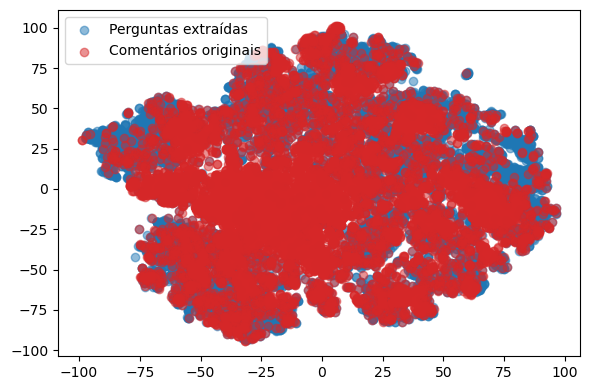

In [31]:
plt.figure(figsize=(6, 4))

plt.scatter(
    comments_2d_[:, 0],
    comments_2d_[:, 1],
    alpha=0.5,
    color="tab:blue",
    label="Perguntas extraídas",
)

plt.scatter(
    original_comments_2d[:, 0],
    original_comments_2d[:, 1],
    alpha=0.5,
    color="tab:red",
    label="Comentários originais",
)

plt.legend()
plt.tight_layout()
plt.show()

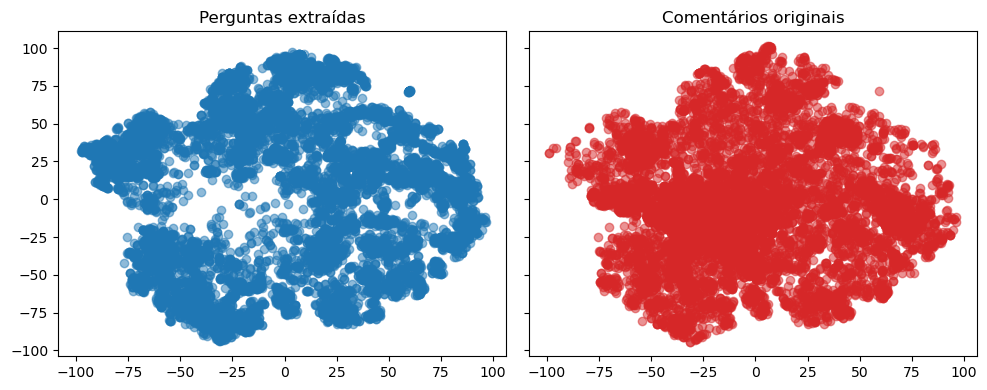

In [32]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    sharex=True,
    sharey=True,
)

axes[0].scatter(
    comments_2d_[:, 0],
    comments_2d_[:, 1],
    alpha=0.5,
    color="tab:blue",
)

axes[0].set_title("Perguntas extraídas")

axes[1].scatter(
    original_comments_2d[:, 0],
    original_comments_2d[:, 1],
    alpha=0.5,
    color="tab:red",
)

axes[1].set_title("Comentários originais")

plt.tight_layout()
plt.show()

In [33]:
df_pairs = df_questions.merge(
    df_comments[["comment_id", "comment"]],
    on="comment_id",
    how="left",
    validate="many_to_one",
)

assert df_pairs["comment"].notna().all()

In [34]:
questions_for_embedding = [
    f"task: sentence similarity | query: {question}"
    for question in df_pairs["perguntas"]
]

comments_for_embedding = [
    f"task: sentence similarity | query: {comment}"
    for comment in df_pairs["comment"]
]

In [35]:
MODEL = SentenceTransformer(MODEL_ID)

question_embeddings = MODEL.encode(
    questions_for_embedding,
    batch_size=8,
    normalize_embeddings=True,
    convert_to_numpy=True,
)

comment_embeddings = MODEL.encode(
    comments_for_embedding,
    batch_size=8,
    normalize_embeddings=True,
    convert_to_numpy=True,
)

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

In [36]:
df_pairs["similaridade"] = np.sum(
    question_embeddings * comment_embeddings,
    axis=1,
)

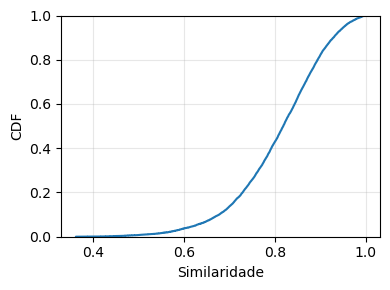

In [37]:
plt.figure(figsize=(4, 3))
sns.ecdfplot(
    data=df_pairs,
    x="similaridade",
)

plt.ylabel('CDF')
plt.xlabel('Similaridade')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()